# End-to-End Machine Learning Project: Credit Card Fraud Detection
**Türkiye Artificial Intelligence Academy - Machine Learning Final Assignment**

## About the Dataset & Why We Chose It
For this project, we are using the **"Credit Card Fraud Detection 2026"** dataset. It contains 20,000 transactions and 26 features. 

**Why did we choose this dataset?**
* **Readable Features:** Unlike classic fraud datasets that hide variables behind meaningless names (like V1, V2... V28 due to PCA anonymization), this dataset has clear, understandable columns (e.g., `merchant_category`, `device_type`, `auth_method`). This makes the data exploration and explainability steps much more meaningful.
* **Real-World Challenge (Imbalanced Data):** Only 1.7% of the transactions in this dataset are fraudulent. This perfectly simulates real-world scenarios where we cannot rely on simple "Accuracy" and must focus on advanced metrics like Precision, Recall, and F1-Score.
* **Modern Payment Scenarios:** It includes up-to-date transaction patterns like crypto-exchanges, biometric authentication, and contactless payments.

---

### Project Roadmap (17-Step Pipeline)

This project follows the 17-step final assignment guidelines to build a complete machine learning pipeline:

* **Step 1 (Docstring):** Add a project docstring explaining the goal, libraries, and running instructions.
* **Step 2 (Data Loading):** Read the dataset using Pandas and briefly explain the problem it solves.
* **Step 3 (Target Variable):** Define the target variable and state the problem type (Classification/Regression).
* **Step 4 (Initial Inspection):** Check the first rows, dimension, data types, and basic statistics.
* **Step 5 (Missing Values):** Check for missing values and handle them appropriately.
* **Step 6 (Encoding):** Convert categorical variables into numerical form using proper encoding methods.
* **Step 7 (Outliers):** Analyze outliers and handle them using removal, capping, or interpretation.
* **Step 8 (Scaling):** Apply feature scaling to numerical variables.
* **Step 9 (Feature Engineering):** Create at least 2 new meaningful features.
* **Step 10 (Feature Selection):** Apply at least one feature selection approach (e.g., correlation analysis).
* **Step 11 (Data Split):** Split the dataset into Train, Validation, and Test sets using stratification.
* **Step 12 (Model Training):** Train at least 3 different machine learning models.
* **Step 13 (Validation Comparison):** Compare the validation performance of the models using classification metrics.
* **Step 14 (Hyperparameter Tuning):** Tune the hyperparameters of the best model using Grid/Random Search.
* **Step 15 (Test Evaluation):** Evaluate the best model on the test set (Confusion Matrix, Precision, Recall, F1-Score).
* **Step 16 (Results Interpretation):** Interpret the results, identify the best model, and discuss limitations.
* **Step 17 (Explainability):** Add a simple interpretability analysis (Feature Importance) for the best model.

## Step 1: Importing Necessary Libraries
In this step, we are importing all the tools (Python libraries) required to build our machine learning pipeline. 

* **Pandas & NumPy:** For data manipulation and mathematical calculations.
* **Matplotlib & Seaborn:** For data visualization.
* **Scikit-Learn (sklearn):** For data preprocessing, model building, and evaluation. We will train and compare **4 different models**: Logistic Regression, Decision Tree, Random Forest, and K-Nearest Neighbors (KNN).

In [1]:

# --- 1. Data Manipulation and Math ---
import pandas as pd
# To read, manipulate, and analyze the data

import numpy as np
# To perform mathematical operations and handle arrays


# --- 2. Data Visualization ---
import matplotlib.pyplot as plt
# To create basic charts and graphs

import seaborn as sns
# To create beautiful statistical graphics


# --- 3. Data Preprocessing & Splitting ---
from sklearn.model_selection import train_test_split
# To split the data into Train, Validation, and Test sets

from sklearn.preprocessing import StandardScaler, LabelEncoder
# To scale numerical features and encode categorical text


# --- 4. Machine Learning Models (We will use 4 models) ---
from sklearn.linear_model import LogisticRegression
# To train the Logistic Regression classification model

from sklearn.tree import DecisionTreeClassifier
# To train the Decision Tree classification model

from sklearn.ensemble import RandomForestClassifier
# To train the Random Forest model (Great for finding Feature Importance)

from sklearn.neighbors import KNeighborsClassifier
# To train the K-Nearest Neighbors (KNN) distance-based model


# --- 5. Model Evaluation & Hyperparameter Tuning ---
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
# To evaluate the performance of our models

from sklearn.model_selection import GridSearchCV
# To find the best hyperparameters automatically


# --- 6. Utilities ---
import warnings
# To ignore unnecessary warning messages and keep the output clean
warnings.filterwarnings('ignore')

## Step 2: Loading the Dataset & Problem Definition

In this step, we load the dataset into a Pandas DataFrame.

**Problem Definition:**
Financial fraud causes massive monetary losses every year. The objective of this dataset and project is to analyze credit card transaction records (amount, authentication method, merchant category, velocity, etc.) and automatically classify whether a transaction is **Legitimate** or **Fraudulent**.

Dataset loaded successfully!
Total Rows: 20000 | Total Columns: 26


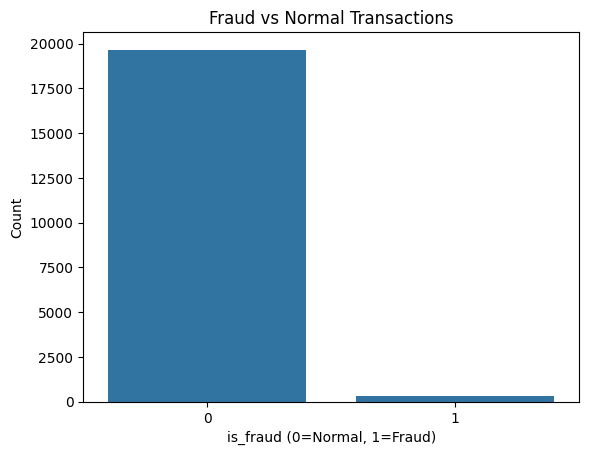

In [2]:
# Define the dataset path from Kaggle input directory
file_path = "/kaggle/input/datasets/uditjain13/credit-card-fraud-detection-2026/credit_card_fraud_2026.csv"
# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)
# Display a success message and show the first 5 rows
print("Dataset loaded successfully!")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}")
# df.shape returns (rows, columns). 0 :rows ,1 : columms
# Display the first 10 rows to inspect the data
df.head(10)

# Check how many fraud and normal transactions we have
sns.countplot(x='is_fraud', data=df)
plt.title('Fraud vs Normal Transactions')
plt.xlabel('is_fraud (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.show()

## Step 3: Defining the Target Variable & Problem Type

Based on the initial dataset overview, our goal is to predict whether a credit card transaction is a fraud or not. 

* **Target Variable:** The column that indicates the fraud status is **`is_fraud`**.
* **Problem Type:** We are predicting between two distinct categories (1 = Fraud, 0 = Legitimate) rather than a continuous number (like price or weight). Therefore, this is clearly a **BINARY CLASSIFICATION** problem, NOT a Regression problem.


Target Variable: 'is_fraud'

Class Counts:
is_fraud
0    19661
1      339
Name: count, dtype: int64

Class Percentages:
is_fraud
0    98.3 %
1     1.7 %
Name: proportion, dtype: object


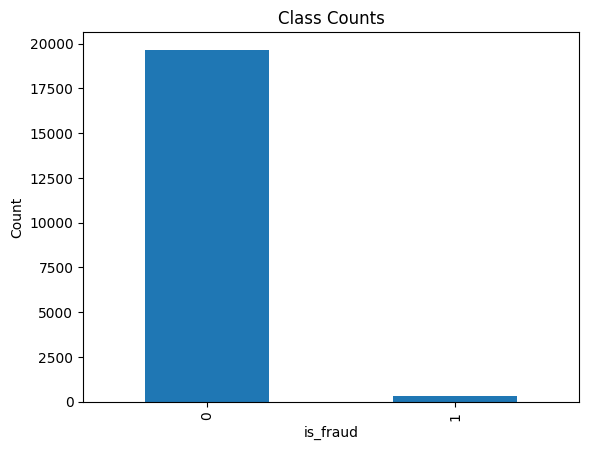

In [3]:
# Defining the target column
target_col = 'is_fraud'
print(f"Target Variable: '{target_col}'\n")

# Why use value_counts()? 
# We use it to see exactly how many legitimate (0) and fraudulent (1) records we have.
# This helps us understand the class distribution and confirms it is a binary classification problem.
class_counts = df[target_col].value_counts()
print("Class Counts:")
print(class_counts)

# Why use normalize=True and multiply by 100?
# Raw numbers can be hard to interpret at a glance. Normalizing gives us the proportions.
# Multiplying by 100 converts these proportions into percentages.
# This clearly shows us how imbalanced the dataset is (98.3% vs 1.7%).
class_percentages = df[target_col].value_counts(normalize=True) * 100

# Why use .round(2) and .astype(str)?
# - .round(2): We round the numbers to 2 decimal places so the output looks clean and easy to read.
# - .astype(str): We convert the numeric percentages into text (strings). 
# We MUST do this because Python does not allow appending a text symbol (' %') directly to a mathematical number.
print("\nClass Percentages:")
print(class_percentages.round(2).astype(str) + ' %')

# Simple bar chart of class_counts
class_counts.plot(kind='bar')
plt.title('Class Counts')
plt.xlabel('is_fraud')
plt.ylabel('Count')
plt.show()

## Step 4: Initial Data Inspection

In this step, we will examine the general structure of our dataset. We need to check the first few rows to see what the data actually looks like, find out the exact number of rows and columns, check the data types of each feature, and look at the basic statistical summary.

First 5 rows of the dataset:


,transaction_id,amount_usd,merchant_category,card_type,auth_method,channel,device_type,is_foreign_transaction,hours_since_last_txn,txn_count_last_24h,...,ip_country_mismatch,billing_shipping_mismatch,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,is_ai_generated_scam_attempt,merchant_risk_score,prior_disputes,is_fraud
0,1,42.86,Restaurants,Visa,OTP,Online,Android Phone,False,13.54,2,...,False,False,0,0.1,18,3,False,42.3,0,0
1,2,4.75,Online Retail,Mastercard,3D Secure,Online,Android Phone,False,0.71,2,...,False,False,0,25.8,12,4,False,28.3,0,0
2,3,77.18,Groceries,Mastercard,3D Secure,Online,Mac,False,0.35,5,...,False,True,0,42.3,5,0,False,24.7,1,0
3,4,1.69,Streaming,Visa,No Authentication,POS,Android Phone,False,3.42,6,...,False,False,0,28.9,22,6,False,56.2,1,0
4,5,261.68,Travel,Visa,3D Secure,In-App,iPhone,False,2.43,2,...,False,False,0,3.9,2,4,False,32.7,0,0



Dataset Shape: 20000 rows and 26 columns

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   transaction_id                20000 non-null  int64  
 1   amount_usd                    20000 non-null  float64
 2   merchant_category             20000 non-null  object 
 3   card_type                     20000 non-null  object 
 4   auth_method                   20000 non-null  object 
 5   channel                       20000 non-null  object 
 6   device_type                   20000 non-null  object 
 7   is_foreign_transaction        20000 non-null  bool   
 8   hours_since_last_txn          20000 non-null  float64
 9   txn_count_last_24h            20000 non-null  int64  
 10  distance_from_home_km         20000 non-null  float64
 11  card_age_months               20000 non-null  int64  
 12  cus

,transaction_id,amount_usd,hours_since_last_txn,txn_count_last_24h,distance_from_home_km,card_age_months,customer_age,account_balance_usd,cvv_retry_count,velocity_score,time_of_day_hour,day_of_week,merchant_risk_score,prior_disputes,is_fraud
count,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.00,20000.0,20000.00,20000.00,20000.00
mean,10000.50,132.42,8.95,3.19,22.14,46.94,49.67,3316.66,0.18,19.81,11.53,3.0,37.40,0.28,0.02
std,5773.65,256.96,8.84,1.78,22.12,6.77,18.49,4350.72,0.42,12.37,6.93,2.0,17.06,0.53,0.13
min,1.00,1.00,0.01,0.00,0.00,22.00,18.00,52.05,0.00,0.00,0.00,0.0,0.00,0.00,0.00
25%,5000.75,26.24,2.59,2.00,6.34,42.00,34.00,1019.14,0.00,10.70,6.00,1.0,25.60,0.00,0.00
50%,10000.50,57.51,6.21,3.00,15.50,47.00,50.00,2007.68,0.00,18.80,12.00,3.0,35.70,0.00,0.00
75%,15000.25,131.75,12.43,4.00,30.82,51.00,66.00,3944.12,0.00,27.60,18.00,5.0,47.30,0.00,0.00
max,20000.00,6872.69,87.05,12.00,216.19,74.00,81.00,127125.86,3.00,74.40,23.00,6.0,100.00,4.00,1.00


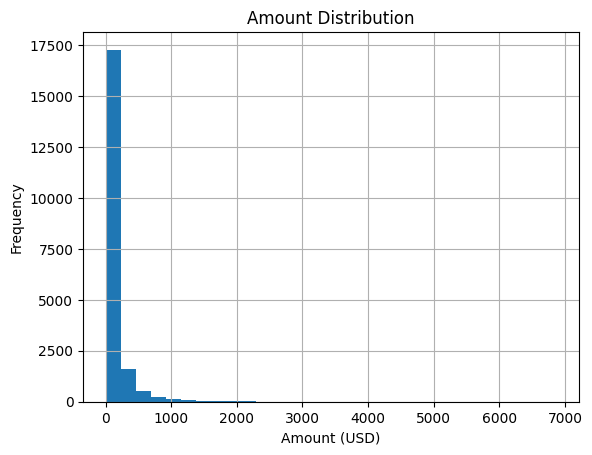

In [4]:
# Why use .head()?
# It returns the first 5 rows of the DataFrame by default. 
# We use it to get a quick visual understanding of what the columns contain and how the values are formatted.
print("First 5 rows of the dataset:")
display(df.head())
pd.set_option('display.max_columns', None)

# Why use .shape?
# It is an attribute (not a method/function, so no parentheses) that returns a tuple: (number_of_rows, number_of_columns).
# We use it to know the exact size of our data before starting any preprocessing.
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# Why use .info()?
# It prints a concise summary of the DataFrame. 
# It shows the column names, non-null counts, and the data type (dtype) of each column.
# We use this to quickly spot if there are any missing values (nulls) and to see which columns are categorical (object/bool) vs numerical (int/float).
print("\nDataset Info:")
df.info()

# Why use .describe()?
# It generates descriptive statistics (count, mean, standard deviation, min, max, and quartiles) for all NUMERICAL COLUMNS.
# We use it to understand the distribution of our numerical data, check the scale of different features, and spot potential extreme values (outliers).
# We chain .round(2) to round the floating-point numbers to 2 decimal places for better readability.
print("\nBasic Statistical Summary:")
display(df.describe().round(2))

# --- WHAT DO THESE STATISTICS MEAN? ---
# 1. count: The number of non-empty rows. Since all show 20,000, it proves we have NO missing numerical data!
# 2. mean: The average value. (For example, the average transaction 'amount_usd' is $132.42).
# 3. std: Standard Deviation. It shows how spread out the data is from the mean. A high 'std' means the values vary a lot.
# 4. min / max: The lowest and highest values. (For example, the maximum transaction amount is $6872.69).
# 5. 25%, 50%, 75% (Quartiles): 50% is the Median. If the 75% mark is much lower than the 'max' value (e.g., 75% of amounts are under $131, but the max is $6872), it is a huge signal that we have OUTLIERS!

# Look at the distribution of amount_usd
df['amount_usd'].hist(bins=30)
plt.title('Amount Distribution')
plt.xlabel('Amount (USD)')
plt.ylabel('Frequency')
plt.show()

## Step 5: Missing Value Check

In this step, we explicitly check if there is any missing data (Null/NaN) in our dataset. Handling missing values is a critical part of data preprocessing. If we find any, we would need to fill them (imputation) or drop them.

--- Missing Values Count per Column ---
transaction_id                  0
amount_usd                      0
merchant_category               0
card_type                       0
auth_method                     0
channel                         0
device_type                     0
is_foreign_transaction          0
hours_since_last_txn            0
txn_count_last_24h              0
distance_from_home_km           0
card_age_months                 0
customer_age                    0
account_balance_usd             0
is_new_merchant                 0
used_vpn                        0
ip_country_mismatch             0
billing_shipping_mismatch       0
cvv_retry_count                 0
velocity_score                  0
time_of_day_hour                0
day_of_week                     0
is_ai_generated_scam_attempt    0
merchant_risk_score             0
prior_disputes                  0
is_fraud                        0
dtype: int64

Total missing values in the entire dataset: 0


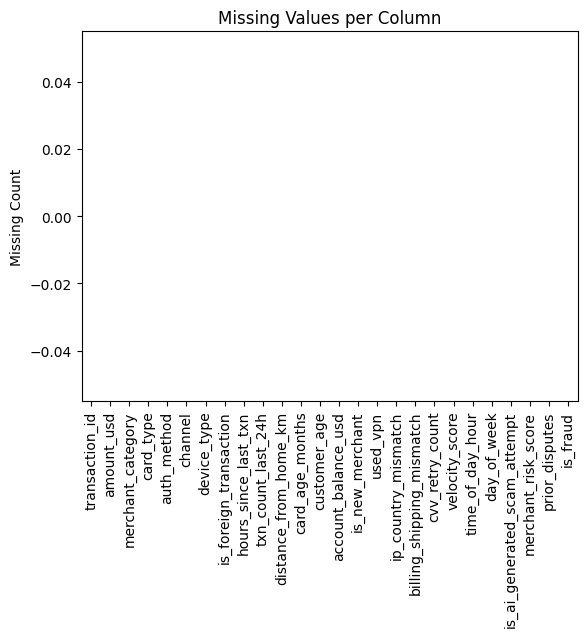

In [5]:

# df.isnull() checks every single cell in the dataframe and returns True if it is missing.
# .sum() adds up those True values column by column.
missing_values = df.isnull().sum()

print("--- Missing Values Count per Column ---")
print(missing_values)

# Let's calculate the total number of missing cells in the entire dataset
total_missing = missing_values.sum()
print(f"\nTotal missing values in the entire dataset: {total_missing}")

# Conclusion note for the assignment
# Since the total is 0, our dataset is perfectly clean in terms of missing data.
# We do not need to apply any filling (imputation) or dropping techniques.

# Bar chart of missing values per column
missing_values.plot(kind='bar')
plt.title('Missing Values per Column')
plt.ylabel('Missing Count')
plt.show()

## Step 6: Identifying Categorical Variables

Before applying any encoding, we first need to find our categorical columns (Object and Boolean types). We will iterate through these columns and use the `.unique()` function to see exactly what kind of text or boolean data they hold. 

Knowing the number of unique values (cardinality) helps us decide which encoding technique (e.g., One-Hot Encoding or Label Encoding) is the most appropriate.

In [6]:
 #FINDING CATEGORICAL VARIABLES


# Why use .select_dtypes()?
# It filters the dataframe columns based on their data types.
# We are only selecting 'object' (text) and 'bool' (True/False) columns.
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

print(f"Total Categorical Columns found: {len(categorical_cols)}\n")

print("--- CATEGORICAL COLUMNS & THEIR UNIQUE VALUES ---")

# We use a 'for' loop to iterate through each categorical column
for x in categorical_cols:
    
    # .nunique() returns the NUMBER of unique values in the column
    num_unique = df[x].nunique()
    
    # .unique() returns the ACTUAL unique values as an array
    unique_vals = df[x].unique()
    
    print(f"-> Column: '{x}' | Unique Values Count: {num_unique}")
    print(f"   Values: {unique_vals}\n")
    
# NOTE: 
# If a column has only True/False, we can just convert it to 1/0.
# If a text column has no hierarchical order (like card_type: Visa, Mastercard), we will use One-Hot Encoding.

Total Categorical Columns found: 11

--- CATEGORICAL COLUMNS & THEIR UNIQUE VALUES ---
-> Column: 'merchant_category' | Unique Values Count: 12
   Values: ['Restaurants' 'Online Retail' 'Groceries' 'Streaming' 'Travel'
 'Gift Cards' 'Electronics' 'Fuel' 'Gaming' 'Utilities' 'Crypto Exchange'
 'Healthcare']

-> Column: 'card_type' | Unique Values Count: 5
   Values: ['Visa' 'Mastercard' 'Amex' 'RuPay' 'Discover']

-> Column: 'auth_method' | Unique Values Count: 5
   Values: ['OTP' '3D Secure' 'No Authentication' 'Biometric' 'PIN']

-> Column: 'channel' | Unique Values Count: 5
   Values: ['Online' 'POS' 'In-App' 'Contactless' 'ATM']

-> Column: 'device_type' | Unique Values Count: 8
   Values: ['Android Phone' 'Mac' 'iPhone' 'POS Terminal' 'ATM Machine' 'Tablet'
 'Windows PC' 'Smart Watch']

-> Column: 'is_foreign_transaction' | Unique Values Count: 2
   Values: [False  True]

-> Column: 'is_new_merchant' | Unique Values Count: 2
   Values: [False  True]

-> Column: 'used_vpn' | Unique 

In [7]:
#FINDING DISCRETE/CATEGORICAL COLUMNS DISGUISED AS NUMBERS


# Select only numerical columns (integers and floats)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("--- POTENTIAL HIDDEN CATEGORICAL COLUMNS (Less than 30 unique values) ---")

# Loop through numerical columns and check their unique value count
for col in numerical_cols:
    num_unique = df[col].nunique()
    
    # If the column has fewer than 30 unique values, print it out
    if num_unique < 30:
        # We use sorted() to display the unique numbers in order
        unique_vals = sorted(df[col].unique())
        
        print(f"-> Column: '{col}' | Unique Values Count: {num_unique}")
        print(f"   Values: {unique_vals}\n")

# NOTE: 'is_fraud' is our target variable. 
# 'txn_count_last_24h' (transaction count) is a discrete numerical variable.
# 'time_of_day_hour' (0-23) and 'day_of_week' (0-6) are cyclical categorical variables.

--- POTENTIAL HIDDEN CATEGORICAL COLUMNS (Less than 30 unique values) ---
-> Column: 'txn_count_last_24h' | Unique Values Count: 13
   Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

-> Column: 'cvv_retry_count' | Unique Values Count: 4
   Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

-> Column: 'time_of_day_hour' | Unique Values Count: 24
   Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

-> Column: 'day_of_week' | Unique Values Count: 7
   Values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

-> Column: 'pri

Shape before encoding: 20000 rows and 26 columns

Encoding completed successfully!
New Shape after encoding: 20000 rows and 78 columns

New Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 78 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   20000 non-null  int64  
 1   amount_usd                       20000 non-null  float64
 2   is_foreign_transaction           20000 non-null  int64  
 3   hours_since_last_txn             20000 non-null  float64
 4   txn_count_last_24h               20000 non-null  int64  
 5   distance_from_home_km            20000 non-null  float64
 6   card_age_months                  20000 non-null  int64  
 7   customer_age                     20000 non-null  int64  
 8   account_balance_usd              20000 non-null  float64
 9   is_new_merchant                  20000 non-null  i

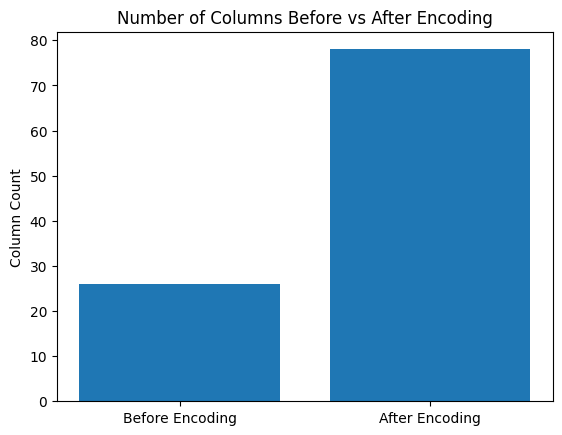

In [8]:
print(f"Shape before encoding: {df.shape[0]} rows and {df.shape[1]} columns")

# --- 1. Converting Boolean (True/False) to 1/0 ---
# Find all columns with 'bool' data type
bool_cols = df.select_dtypes(include=['bool']).columns
# .astype(int) maps True to 1 and False to 0
df[bool_cols] = df[bool_cols].astype(int)

# --- 2. Handling Hidden Categorical Variables ---
# We change their type to 'str' (string/text).
# This prevents the model from thinking 23:00 is mathematically "greater" than 01:00.
df['day_of_week'] = df['day_of_week'].astype(str)
df['time_of_day_hour'] = df['time_of_day_hour'].astype(str)

# Save the column count before encoding for our chart
cols_before = df.shape[1]

# --- 3. One-Hot Encoding ---
# pd.get_dummies() finds all 'object' (text) columns and converts them into 1/0 columns.
# drop_first=True removes the first generated column for each category.
# We do this to prevent the "Dummy Variable Trap" (multicollinearity), which confuses linear models.
# dtype=int ensures the output values are 1 and 0 (instead of True/False).
df = pd.get_dummies(df, drop_first=True, dtype=int)

print("\nEncoding completed successfully!")
print(f"New Shape after encoding: {df.shape[0]} rows and {df.shape[1]} columns")

# Display the new dataset info to prove EVERYTHING is now a number (int or float)
print("\nNew Dataset Info:")
df.info()

# Compare number of columns before and after encoding
cols_after = df.shape[1]
plt.bar(['Before Encoding', 'After Encoding'], [cols_before, cols_after])
plt.title('Number of Columns Before vs After Encoding')
plt.ylabel('Column Count')
plt.show()

## Step 7: Outlier Analysis
In this step, we check for outliers in our numeric columns. Outliers are values that are much higher or lower than the rest of the data.
We only check continuous numeric columns (like amount_usd or distance_from_home_km). We do not check binary (0/1) columns, because the idea of an "outlier" does not apply to binary data.

We use the IQR method to count outliers, and a boxplot to compare amount_usd between fraud and normal transactions.
**We decided not to delete the outliers**. In fraud detection, unusual values (like a very high amount) can actually be a sign of fraud, not an error. So instead of removing them, we chose to keep and interpret them.

--- Outliers using 1.5 IQR rule ---
amount_usd: 1656 outliers
hours_since_last_txn: 553 outliers
txn_count_last_24h: 104 outliers
distance_from_home_km: 519 outliers
card_age_months: 11 outliers
customer_age: 0 outliers
account_balance_usd: 1129 outliers
cvv_retry_count: 3342 outliers
velocity_score: 50 outliers
merchant_risk_score: 94 outliers
prior_disputes: 4915 outliers


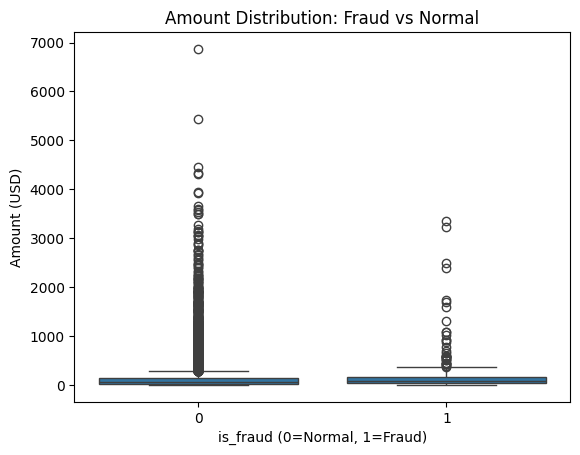

In [9]:
## Step 7: Outlier Analysis

# We only check continuous numeric columns, not binary (0/1) columns
continuous_cols = [
    'amount_usd', 'hours_since_last_txn', 'txn_count_last_24h',
    'distance_from_home_km', 'card_age_months', 'customer_age',
    'account_balance_usd', 'cvv_retry_count', 'velocity_score',
    'merchant_risk_score', 'prior_disputes'
]

# Count outliers using the IQR method
print("--- Outliers using 1.5 IQR rule ---")
for col in continuous_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 2 * IQR
    upper_bound = Q3 + 2 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

# Visualize: compare amount_usd between fraud and normal transactions
sns.boxplot(x='is_fraud', y='amount_usd', data=df)
plt.title('Amount Distribution: Fraud vs Normal')
plt.xlabel('is_fraud (0=Normal, 1=Fraud)')
plt.ylabel('Amount (USD)')
plt.show()

# NOTE:
# We are NOT deleting these outliers.
# In fraud detection, unusual values (like a very high amount) can be a sign of fraud, not a mistake.
# So we choose to KEEP and INTERPRET them instead of removing them.

## Step 8: Feature Scaling
In this step, we scale our numeric columns. Scaling means changing the numbers so they are all on a similar range.
Some models (like Logistic Regression and KNN) use distance or math formulas that are affected 
by the size of numbers. 
*If one column is like 0-1 and another is like 0-100000, the model may think the*
 **bigger numbers are more important, even if they are not.**

We use StandardScaler from sklearn. It transforms each column so it has a mean of 0 and a 
standard deviation of 1.
We only scale the continuous numeric columns. We do NOT scale the binary (0/1) columns, 
because scaling them does not make sense and can actually make the data harder to understand.

Scaling completed!
       amount_usd  hours_since_last_txn  txn_count_last_24h  \
count    20000.00              20000.00            20000.00   
mean        -0.00                  0.00               -0.00   
std          1.00                  1.00                1.00   
min         -0.51                 -1.01               -1.79   
25%         -0.41                 -0.72               -0.67   
50%         -0.29                 -0.31               -0.11   
75%         -0.00                  0.39                0.45   
max         26.23                  8.84                4.95   

       distance_from_home_km  card_age_months  customer_age  \
count               20000.00         20000.00      20000.00   
mean                   -0.00            -0.00         -0.00   
std                     1.00             1.00          1.00   
min                    -1.00            -3.68         -1.71   
25%                    -0.71            -0.73         -0.85   
50%                    -0.30       

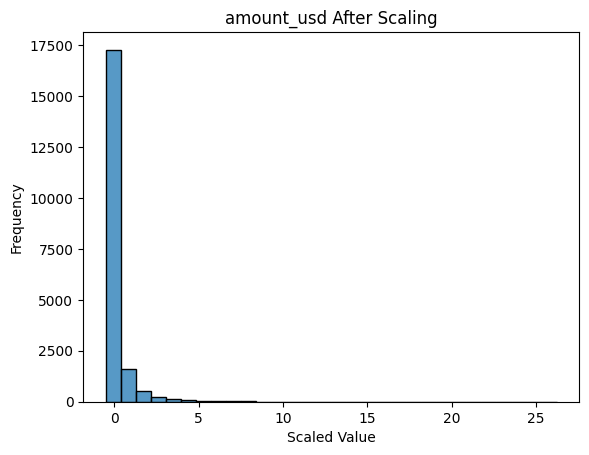

In [10]:
## Step 8: Feature Scaling

# Same continuous columns we used in Step 7


# Why StandardScaler?
# It changes each column so the mean becomes 0 and the standard deviation becomes 1.
# This makes all numeric columns comparable in size.
scaler = StandardScaler()

# Why fit_transform()?
# .fit() learns the mean and standard deviation of each column.
# .transform() actually applies the scaling using those values.
# fit_transform() does both steps at once.
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print("Scaling completed!")
print(df[continuous_cols].describe().round(2))

# Small visualization: check amount_usd after scaling
sns.histplot(df['amount_usd'], bins=30)
plt.title('amount_usd After Scaling')
plt.xlabel('Scaled Value')
plt.ylabel('Frequency')
plt.show()

In [11]:
## Quick Sanity Check Before Moving to Step 9

# 1. Check the shape of our data (rows should still be 20000)
print(f"Current shape: {df.shape[0]} rows, {df.shape[1]} columns")

# 2. Check that ALL columns are now numeric (no text/object columns left)
print("\nColumn data types:")
print(df.dtypes.value_counts())

# 3. Check there are no missing values introduced during scaling/encoding
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# 4. Check that our target column is still binary (0/1) and untouched
print("\nis_fraud value counts (should still be 19661 / 339):")
print(df['is_fraud'].value_counts())

# 5. Quick look at a few rows to visually confirm everything looks right
df.head()

# transaction_id is just a row identifier, not a real feature.
# It has no predictive value, so we drop it before moving forward.
df = df.drop(columns=['transaction_id'])

print(f"Shape after dropping transaction_id: {df.shape[0]} rows, {df.shape[1]} columns")

Current shape: 20000 rows, 78 columns

Column data types:
int64      67
float64    11
Name: count, dtype: int64

Total missing values: 0

is_fraud value counts (should still be 19661 / 339):
is_fraud
0    19661
1      339
Name: count, dtype: int64
Shape after dropping transaction_id: 20000 rows, 77 columns


## Step 9: Feature Engineering
In this step, we create 2 new features using the columns we already have.


****Note:** Ideally, feature engineering should happen before scaling, so ratios and sums use real values instead of scaled ones. We already scaled some columns in Step 8, so our new features are a simplified version, but the idea and process are the same.**


**New Feature 1: risk_flag_count**
We count how many "suspicious" binary flags are True for each transaction 
(foreign transaction, VPN used, IP mismatch, billing/shipping mismatch, AI scam attempt). 
More flags turned on could mean higher fraud risk.
**New Feature 2: balance_to_amount_ratio**
We compare account balance to transaction amount. A very high or very low ratio 
could be unusual behavior.

New features created!
New shape: 20000 rows, 79 columns


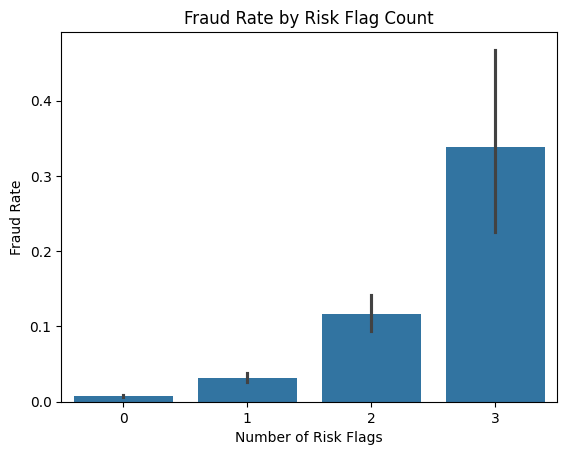

In [12]:
## Step 9: Feature Engineering

# --- New Feature 1: risk_flag_count ---
# Why? Instead of looking at 5 separate 0/1 columns, we combine them into ONE number.
# This tells us how many "risk signals" are present in a single transaction.
risk_flags = ['is_foreign_transaction', 'used_vpn', 'ip_country_mismatch', 
              'billing_shipping_mismatch', 'is_ai_generated_scam_attempt']

df['risk_flag_count'] = df[risk_flags].sum(axis=1)

# --- New Feature 2: balance_to_amount_ratio ---
# Why? This compares how big the transaction is compared to the account balance.
# We add a small number (1e-5) to avoid dividing by zero.
df['balance_to_amount_ratio'] = df['account_balance_usd'] / (df['amount_usd'] + 1e-5)

print("New features created!")
print(f"New shape: {df.shape[0]} rows, {df.shape[1]} columns")
df[['risk_flag_count', 'balance_to_amount_ratio']].describe()

# Small visualization: does risk_flag_count relate to fraud?
sns.barplot(x='risk_flag_count', y='is_fraud', data=df)
plt.title('Fraud Rate by Risk Flag Count')
plt.xlabel('Number of Risk Flags')
plt.ylabel('Fraud Rate')
plt.show()

## Step 10: Feature Selection
In this step, we choose which features are actually useful for predicting fraud.

We use correlation analysis. We check how much each column is related to our target 
column (is_fraud). A correlation close to 0 means the column has almost no relationship 
with fraud, so it may not help the model.



--- Correlation with is_fraud (Top 10) ---
is_fraud                         1.000000
risk_flag_count                  0.182941
cvv_retry_count                  0.155509
ip_country_mismatch              0.117763
merchant_risk_score              0.107680
billing_shipping_mismatch        0.100863
velocity_score                   0.097255
is_foreign_transaction           0.083494
is_ai_generated_scam_attempt     0.078941
auth_method_No Authentication    0.078271
Name: is_fraud, dtype: float64

--- Correlation with is_fraud (Bottom 10, weakest) ---
time_of_day_hour_18               -0.012812
time_of_day_hour_12               -0.013977
time_of_day_hour_13               -0.015518
merchant_category_Groceries       -0.015715
merchant_category_Restaurants     -0.016246
device_type_Windows PC            -0.017740
auth_method_PIN                   -0.021669
merchant_category_Online Retail   -0.026659
hours_since_last_txn              -0.028798
auth_method_Biometric             -0.030453
Name: is_f

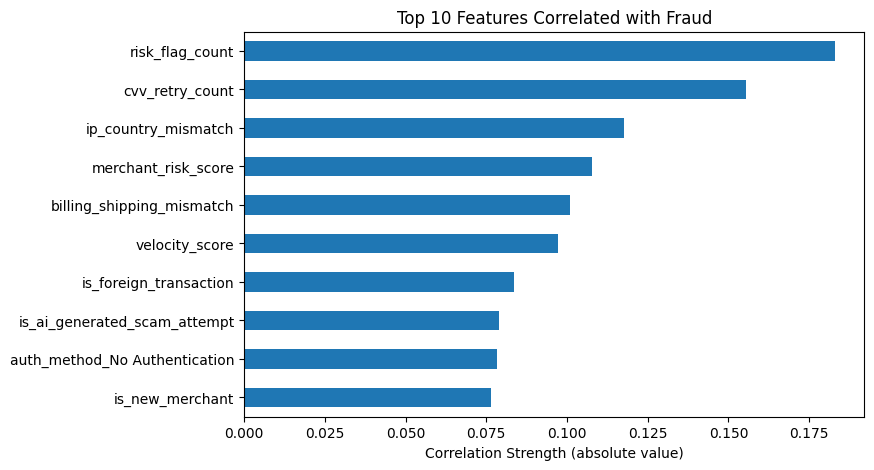

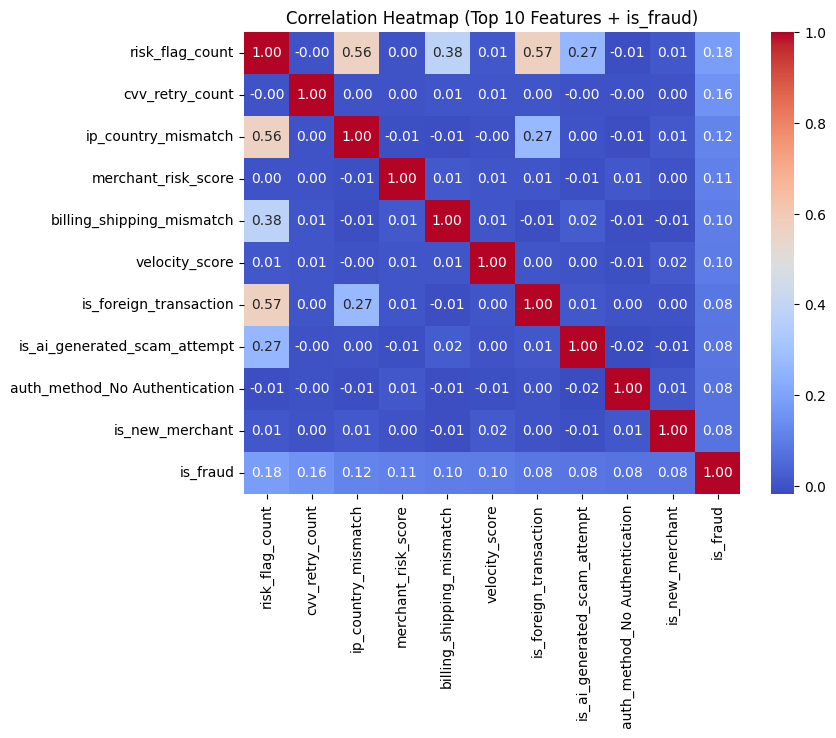

In [13]:
## Step 10: Feature Selection (Correlation Analysis)

# Why correlation? 
# It shows us how strongly each column moves together with is_fraud.
# Values close to 1 or -1 mean strong relationship. Values close to 0 mean weak relationship.
correlations = df.corr()['is_fraud'].sort_values(ascending=False)

print("--- Correlation with is_fraud (Top 10) ---")
print(correlations.head(10))

print("\n--- Correlation with is_fraud (Bottom 10, weakest) ---")
print(correlations.tail(10))

# Small visualization: top 10 correlated features with fraud
plt.figure(figsize=(8,5))
correlations.drop('is_fraud').abs().sort_values(ascending=False).head(10).plot(kind='barh')
plt.title('Top 10 Features Correlated with Fraud')
plt.xlabel('Correlation Strength (absolute value)')
plt.gca().invert_yaxis()
plt.show()

# Heatmap: correlation between the top 10 features and is_fraud
top_features = correlations.drop('is_fraud').abs().sort_values(ascending=False).head(10).index.tolist()
top_features.append('is_fraud')

plt.figure(figsize=(8,6))
sns.heatmap(df[top_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Top 10 Features + is_fraud)')
plt.show()

We first tried a threshold of 0.02, but this removed more than half of our columns, 
including some that make sense (like account_balance_usd) and even our own engineered 
feature (balance_to_amount_ratio). This was too aggressive.

We lowered the threshold to 0.005. This only removes columns with almost zero 
relationship to fraud, and keeps more useful information for the model.

Number of weak columns to drop: 17
Weak columns: ['card_type_Discover', 'time_of_day_hour_20', 'account_balance_usd', 'device_type_Tablet', 'merchant_category_Utilities', 'device_type_Mac', 'device_type_Smart Watch', 'time_of_day_hour_17', 'time_of_day_hour_16', 'day_of_week_1', 'device_type_POS Terminal', 'balance_to_amount_ratio', 'device_type_iPhone', 'day_of_week_5', 'channel_In-App', 'distance_from_home_km', 'day_of_week_2']

Shape after dropping weak columns: 20000 rows, 62 columns


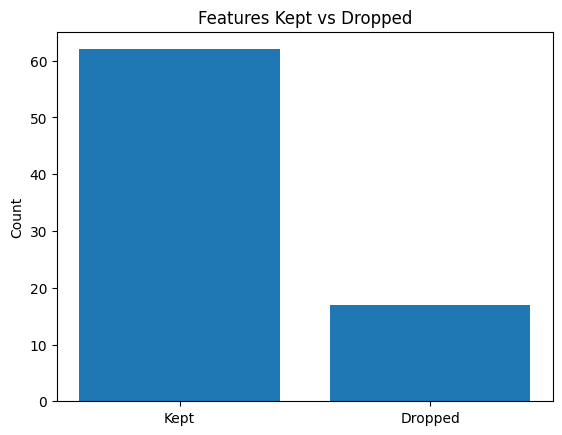

In [14]:
## Step 10 (continued): Removing Weak Features (revised threshold)

# Lower threshold: only drop columns with almost no relationship to fraud
threshold = 0.005

abs_corr = correlations.drop('is_fraud').abs()
weak_cols = abs_corr[abs_corr < threshold].index.tolist()

print(f"Number of weak columns to drop: {len(weak_cols)}")
print("Weak columns:", weak_cols)

df = df.drop(columns=weak_cols)

print(f"\nShape after dropping weak columns: {df.shape[0]} rows, {df.shape[1]} columns")

plt.bar(['Kept', 'Dropped'], [df.shape[1], len(weak_cols)])
plt.title('Features Kept vs Dropped')
plt.ylabel('Count')
plt.show()

## Step 11: Train / Validation / Test Split
In this step, we split our data into three parts:
- **Train set:** used to train the models
- **Validation set:** used to compare models and choose the best one
- **Test set:** used only at the end, to check the final performance

We use `stratify` because our data is imbalanced (only 1.7% fraud). Stratify makes sure 
each set (train, validation, test) has a similar fraud ratio, instead of randomly ending up 
with too much or too little fraud in one set.

We split the data into 70% train, 15% validation, and 15% test.

Train shape: (14000, 61)
Validation shape: (3000, 61)
Test shape: (3000, 61)

Fraud ratio in each set:
Train: 0.0169
Validation: 0.0170
Test: 0.0170


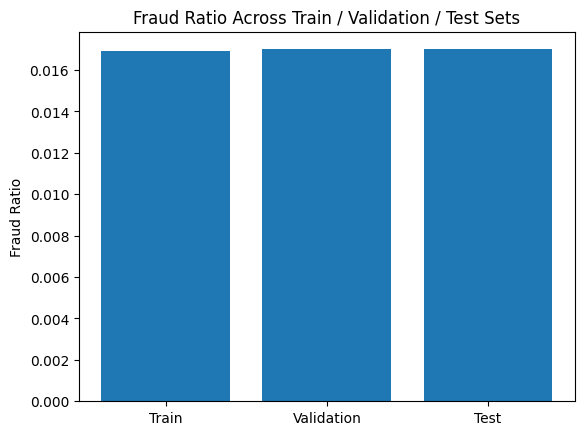

In [16]:
# Separate features (X) and target (y)
X = df.drop(columns=['is_fraud'])
y = df['is_fraud']

# Why stratify=y?
# Our data is imbalanced (only 1.7% fraud). Stratify makes sure the fraud ratio 
# stays the same in train, validation, and test sets

# First split: 70% train, 30% temp (temp will become validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Second split: split temp 50/50 -> 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Train shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

# Check fraud ratio in each set (should be similar, around 1.7%)
print("\nFraud ratio in each set:")
print(f"Train: {y_train.mean():.4f}")
print(f"Validation: {y_val.mean():.4f}")
print(f"Test: {y_test.mean():.4f}")

# Small visualization: fraud ratio comparison across sets
ratios = [y_train.mean(), y_val.mean(), y_test.mean()]
plt.bar(['Train', 'Validation', 'Test'], ratios)
plt.title('Fraud Ratio Across Train / Validation / Test Sets')
plt.ylabel('Fraud Ratio')
plt.show()

## Step 12: Training Multiple Models
In this step, we train 4 different classification models:
- **Logistic Regression:** a simple linear model, good as a baseline
- **Decision Tree:** splits data using simple yes/no rules
- **Random Forest:** combines many decision trees, usually performs well
- **KNN:** looks at the closest data points to make a prediction

We train each model on the training set, then check accuracy on the validation set.

Logistic Regression - Validation Accuracy: 0.9833
Decision Tree - Validation Accuracy: 0.9740
Random Forest - Validation Accuracy: 0.9830
KNN - Validation Accuracy: 0.9833


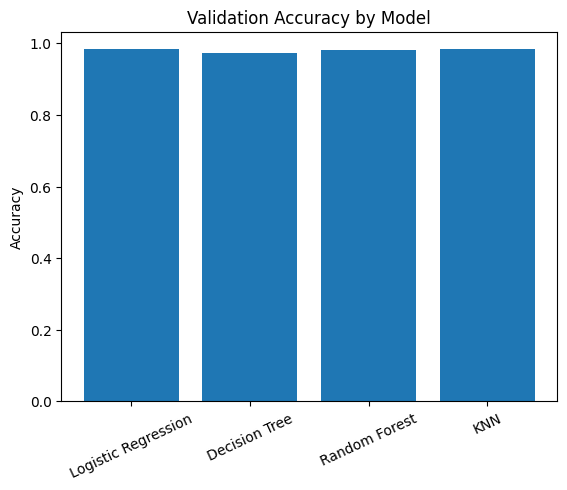

In [18]:

# We put all 4 models into a dictionary.
# This makes it easy to loop through them instead of writing the same code 4 times.
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

# Why random_state=42?
# Some models (like Decision Tree and Random Forest) use randomness when they are built.
# If we don't fix this randomness, we would get slightly different results every time we run the code.
# Setting random_state to a fixed number (42 is just a common choice, any number works)
# makes our results reproducible - we get the SAME result every time we run this cell.
# Note: KNN does not use randomness, so it does not need random_state.

# Dictionary to store predictions for each model (we will use this in Step 13)
val_predictions = {}

# Loop through each model in our dictionary
for name, model in models.items():
    
    # Why .fit()?
    # This is the training step. The model looks at X_train (the features) 
    # and y_train (the correct answers) and learns the patterns between them.
    model.fit(X_train, y_train)
    
    # Why .predict()?
    # Now that the model is trained, we ask it to guess the labels (fraud or not fraud)
    # for the validation set, which it has NOT seen before.
    y_val_pred = model.predict(X_val)
    
    # Save the predictions so we can use them again in Step 13
    val_predictions[name] = y_val_pred
    
    # Why (y_val_pred == y_val).mean()?
    # This compares our predictions to the real answers.
    # It creates a list of True/False values (True = correct guess).
    # .mean() treats True as 1 and False as 0, so this gives us the percentage of correct guesses.
    accuracy = (y_val_pred == y_val).mean()
    print(f"{name} - Validation Accuracy: {accuracy:.4f}")

# Small visualization: compare accuracy across models
accuracies = [(y_val == val_predictions[name]).mean() for name in models.keys()]
plt.bar(models.keys(), accuracies)
plt.title('Validation Accuracy by Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=25)
plt.show()

## Step 13: Comparing Models with the Right Metrics
Accuracy is misleading here, because our data is imbalanced (only 1.7% fraud). A model 
that always predicts "not fraud" would still get about 98% accuracy, but it would be useless.

Instead, we look at these metrics:

- **Precision:** Out of all transactions the model marked as fraud, how many were actually fraud? 
  High precision means fewer false alarms.
- **Recall:** Out of all the real fraud cases, how many did the model catch? 
  High recall means we miss fewer frauds.
- **F1-Score:** A balance between precision and recall. Useful when we care about both.
- **Confusion Matrix:** A table showing exactly how many predictions were correct or wrong, 
  broken down by type (true fraud caught, false alarms, missed frauds, etc).

For fraud detection, **recall is very important** - missing a real fraud case (a false negative) 
is usually more costly than a false alarm.


===== Logistic Regression =====
Precision: 0.5294  -> When model says FRAUD, it is correct 52.9% of the time
Recall:    0.1765  -> Model catches 17.6% of all real fraud cases
F1-Score:  0.2647
Confusion Matrix:
[[   9   42]
 [   8 2941]]


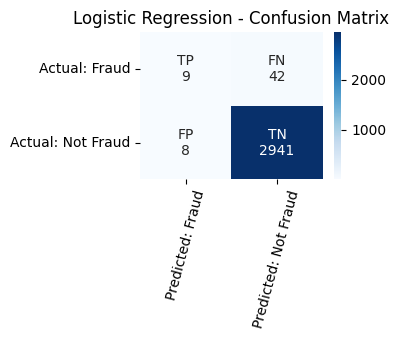


===== Decision Tree =====
Precision: 0.2128  -> When model says FRAUD, it is correct 21.3% of the time
Recall:    0.1961  -> Model catches 19.6% of all real fraud cases
F1-Score:  0.2041
Confusion Matrix:
[[  10   41]
 [  37 2912]]


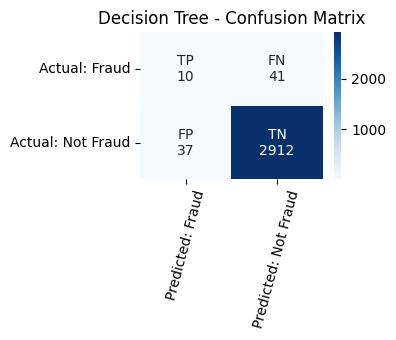


===== Random Forest =====
Precision: 0.0000  -> When model says FRAUD, it is correct 0.0% of the time
Recall:    0.0000  -> Model catches 0.0% of all real fraud cases
F1-Score:  0.0000
Confusion Matrix:
[[   0   51]
 [   0 2949]]


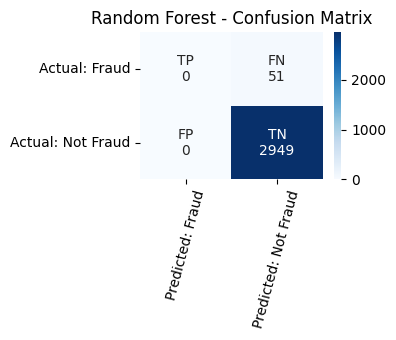


===== KNN =====
Precision: 0.6667  -> When model says FRAUD, it is correct 66.7% of the time
Recall:    0.0392  -> Model catches 3.9% of all real fraud cases
F1-Score:  0.0741
Confusion Matrix:
[[   2   49]
 [   1 2948]]


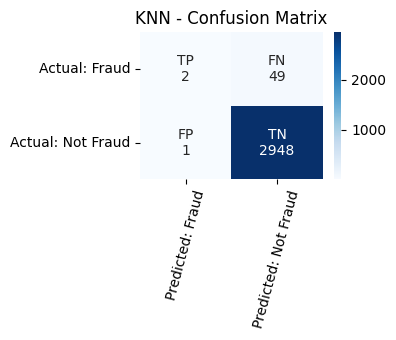

In [27]:
for name, y_val_pred in val_predictions.items():
    
    print(f"\n===== {name} =====")
    
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    
    print(f"Precision: {precision:.4f}  -> When model says FRAUD, it is correct {precision*100:.1f}% of the time")
    print(f"Recall:    {recall:.4f}  -> Model catches {recall*100:.1f}% of all real fraud cases")
    print(f"F1-Score:  {f1:.4f}")
    
    # Why labels=[1, 0]?
    # By default, sklearn puts class 0 (Not Fraud) first. 
    # We want Fraud (class 1) first instead, so the layout follows the classic order:
    # [ TP  FN ]
    # [ FP  TN ]
    cm = confusion_matrix(y_val, y_val_pred, labels=[1, 0])
    print("Confusion Matrix:")
    print(cm)
    
    # Now with labels=[1,0]:
    # row0 = Actual: Fraud, row1 = Actual: Not Fraud
    # col0 = Predicted: Fraud, col1 = Predicted: Not Fraud
    # cm[0,0] = TP, cm[0,1] = FN, cm[1,0] = FP, cm[1,1] = TN
    labels_text = np.array([
        [f"TP\n{cm[0,0]}", f"FN\n{cm[0,1]}"],
        [f"FP\n{cm[1,0]}", f"TN\n{cm[1,1]}"]
    ])
    
    plt.figure(figsize=(4,3.5))
    sns.heatmap(cm, annot=labels_text, fmt='', cmap='Blues',
                xticklabels=['Predicted: Fraud', 'Predicted: Not Fraud'],
                yticklabels=['Actual: Fraud', 'Actual: Not Fraud'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xticks(rotation=75)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Step 14: Hyperparameter Tuning (Top 2 Models)
The assignment asks us to tune the best model, but we decided to tune our **top 2 models** 
based on F1-Score from Step 13: **Logistic Regression** and **Decision Tree**.

We use GridSearchCV to try different hyperparameter combinations and find the best one. 
We also add `class_weight='balanced'` this time. This tells the model to pay more attention 
to the minority class (fraud), since our data is imbalanced (only 1.7% fraud).

We use F1-Score as our scoring metric, because it balances precision and recall, which is 
more important than accuracy for this problem.

Best Logistic Regression parameters: {'C': 0.1, 'class_weight': 'balanced'}
Best cross-validation F1-Score: 0.2149603665546183

Best Decision Tree parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 2}
Best cross-validation F1-Score: 0.14533982030840853

--- Validation Results After Tuning ---

===== Logistic Regression (tuned) =====
Precision: 0.1219
Recall:    0.8627
F1-Score:  0.2136
Confusion Matrix:
[[  44    7]
 [ 317 2632]]

===== Decision Tree (tuned) =====
Precision: 0.0837
Recall:    0.4118
F1-Score:  0.1391
Confusion Matrix:
[[  21   30]
 [ 230 2719]]


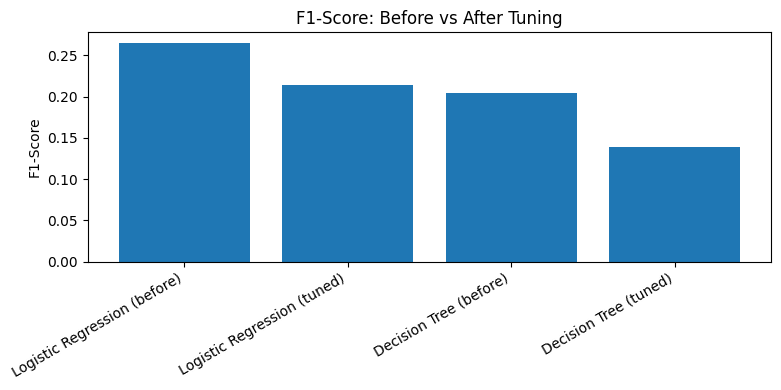

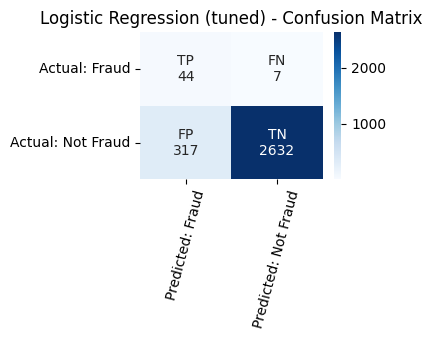

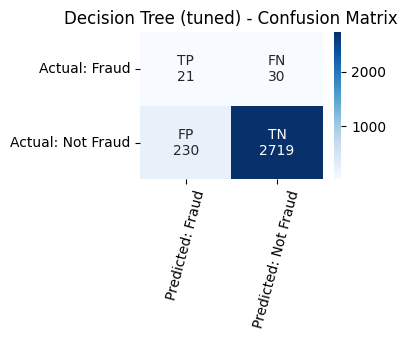

In [29]:

# --- 1. Tuning Logistic Regression ---

# Why these parameters?
# C: controls regularization strength. Smaller C = simpler model, larger C = more complex model.
# class_weight='balanced': makes the model pay more attention to the fraud class.
log_reg_params = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': ['balanced']
}

# Why GridSearchCV?
# It automatically tries every combination of parameters and picks the best one,
# using cross-validation to avoid overfitting to a single train/test split.
# scoring='f1' means it picks the combination with the best F1-Score, not accuracy.
log_reg_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=log_reg_params,
    scoring='f1',
    cv=5
)

# Why .fit()? This runs the grid search: trains and evaluates the model for every parameter combination.
log_reg_grid.fit(X_train, y_train)

print("Best Logistic Regression parameters:", log_reg_grid.best_params_)
print("Best cross-validation F1-Score:", log_reg_grid.best_score_)

# --- 2. Tuning Decision Tree ---

# Why these parameters?
# max_depth: limits how deep the tree can grow (prevents overfitting).
# min_samples_split: minimum number of samples needed to split a node.
tree_params = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid=tree_params,
    scoring='f1',
    cv=5
)

tree_grid.fit(X_train, y_train)

print("\nBest Decision Tree parameters:", tree_grid.best_params_)
print("Best cross-validation F1-Score:", tree_grid.best_score_)

# --- 3. Evaluating Tuned Models on Validation Set ---

# Why do we do this?
# GridSearch's "best_score_" comes from cross-validation on the training data.
# We now check how the tuned models actually perform on the validation set,
# which they have never seen before.

# .best_estimator_ gives us the model that was trained with the best parameters found
best_log_reg = log_reg_grid.best_estimator_
best_tree = tree_grid.best_estimator_

tuned_predictions = {
    'Logistic Regression (tuned)': best_log_reg.predict(X_val),
    'Decision Tree (tuned)': best_tree.predict(X_val)
}

print("\n--- Validation Results After Tuning ---")
for name, y_val_pred in tuned_predictions.items():
    precision = precision_score(y_val, y_val_pred)
    recall = recall_score(y_val, y_val_pred)
    f1 = f1_score(y_val, y_val_pred)
    
    print(f"\n===== {name} =====")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-Score:  {f1:.4f}")
    
    cm = confusion_matrix(y_val, y_val_pred, labels=[1, 0])
    print("Confusion Matrix:")
    print(cm)

# --- 4. Visualization: Before vs After Tuning F1-Score Comparison ---
comparison = {
    'Logistic Regression (before)': f1_score(y_val, val_predictions['Logistic Regression']),
    'Logistic Regression (tuned)': f1_score(y_val, tuned_predictions['Logistic Regression (tuned)']),
    'Decision Tree (before)': f1_score(y_val, val_predictions['Decision Tree']),
    'Decision Tree (tuned)': f1_score(y_val, tuned_predictions['Decision Tree (tuned)'])
}

plt.figure(figsize=(8,4))
plt.bar(comparison.keys(), comparison.values())
plt.title('F1-Score: Before vs After Tuning')
plt.ylabel('F1-Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

for name, y_val_pred in tuned_predictions.items():
    
    cm = confusion_matrix(y_val, y_val_pred, labels=[1, 0])
    
    # Same labeling style we used in Step 13:
    # row0 = Actual: Fraud, row1 = Actual: Not Fraud
    # col0 = Predicted: Fraud, col1 = Predicted: Not Fraud
    labels_text = np.array([
        [f"TP\n{cm[0,0]}", f"FN\n{cm[0,1]}"],
        [f"FP\n{cm[1,0]}", f"TN\n{cm[1,1]}"]
    ])
    
    plt.figure(figsize=(4,3.5))
    sns.heatmap(cm, annot=labels_text, fmt='', cmap='Blues',
                xticklabels=['Predicted: Fraud', 'Predicted: Not Fraud'],
                yticklabels=['Actual: Fraud', 'Actual: Not Fraud'])
    plt.title(f'{name} - Confusion Matrix')
    plt.xticks(rotation=75)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Step 14 (continued): Adjusting the Decision Threshold
By default, a model predicts "Fraud" only if it is more than 50% confident. We can lower 
this threshold to make the model more "cautious" - flagging more transactions as fraud, 
even if it is less sure.

This means more false alarms (FP), but fewer missed frauds (FN). For our project, this is 
a good trade-off: reviewing a few extra transactions is much cheaper than missing real fraud.

We use `predict_proba()` instead of `predict()` to get the fraud probability for each 
transaction, then apply our own custom threshold.

--- Comparing Different Thresholds (Logistic Regression tuned) ---

Threshold: 0.5
Precision: 0.1219 | Recall: 0.8627 | F1: 0.2136
TP: 44 | FN: 7 | FP: 317 | TN: 2632

Threshold: 0.3
Precision: 0.0809 | Recall: 0.8824 | F1: 0.1483
TP: 45 | FN: 6 | FP: 511 | TN: 2438

Threshold: 0.2
Precision: 0.0619 | Recall: 0.8824 | F1: 0.1157
TP: 45 | FN: 6 | FP: 682 | TN: 2267

Threshold: 0.1
Precision: 0.0448 | Recall: 0.9216 | F1: 0.0855
TP: 47 | FN: 4 | FP: 1002 | TN: 1947


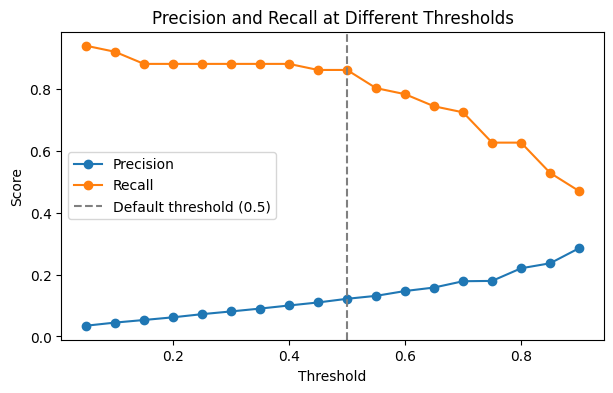

In [30]:
## Step 14 (continued): Adjusting the Decision Threshold

# Why predict_proba() instead of predict()?
# predict() only gives us the final 0/1 decision using a fixed 50% threshold.
# predict_proba() gives us the actual probability of fraud for each transaction,
# so we can choose our own threshold instead of the default 50%.
y_val_proba = best_log_reg.predict_proba(X_val)[:, 1]
# [:, 1] selects the probability of class 1 (Fraud)

# Try a few different thresholds and compare results
thresholds = [0.5, 0.3, 0.2, 0.1]

print("--- Comparing Different Thresholds (Logistic Regression tuned) ---")
for t in thresholds:
    # If probability >= threshold, we predict Fraud (1), otherwise Not Fraud (0)
    y_pred_custom = (y_val_proba >= t).astype(int)
    
    precision = precision_score(y_val, y_pred_custom)
    recall = recall_score(y_val, y_pred_custom)
    f1 = f1_score(y_val, y_pred_custom)
    cm = confusion_matrix(y_val, y_pred_custom, labels=[1, 0])
    
    print(f"\nThreshold: {t}")
    print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
    print(f"TP: {cm[0,0]} | FN: {cm[0,1]} | FP: {cm[1,0]} | TN: {cm[1,1]}")

# Visualization: how precision and recall change with threshold
precisions = []
recalls = []
test_thresholds = np.arange(0.05, 0.95, 0.05)

for t in test_thresholds:
    y_pred_custom = (y_val_proba >= t).astype(int)
    precisions.append(precision_score(y_val, y_pred_custom, zero_division=0))
    recalls.append(recall_score(y_val, y_pred_custom))

plt.figure(figsize=(7,4))
plt.plot(test_thresholds, precisions, label='Precision', marker='o')
plt.plot(test_thresholds, recalls, label='Recall', marker='o')
plt.axvline(0.5, color='gray', linestyle='--', label='Default threshold (0.5)')
plt.title('Precision and Recall at Different Thresholds')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.show()

## Step 15: Final Evaluation on Test Set
In this step, we evaluate our final model - **Logistic Regression (tuned)** with threshold 0.5 - 
on the test set. This is data the model has never seen before, not even during validation 
or tuning. This gives us the most honest estimate of how the model would perform in real use.

We report accuracy, precision, recall, F1-score, and the confusion matrix.

Remember: accuracy is not very meaningful here because our data is imbalanced. We focus more 
on recall (catching fraud) and precision (avoiding false alarms).

===== Final Model: Logistic Regression (tuned) - TEST SET RESULTS =====
Accuracy:  0.8937
Precision: 0.1149  -> When model says FRAUD, it is correct 11.5% of the time
Recall:    0.7843  -> Model catches 78.4% of all real fraud cases
F1-Score:  0.2005

Confusion Matrix:
[[  40   11]
 [ 308 2641]]


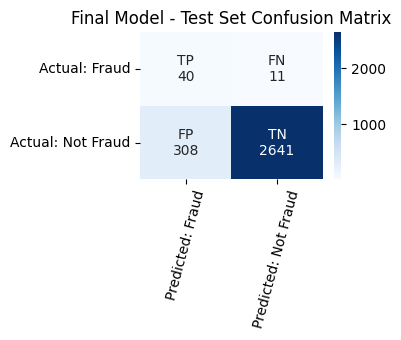

In [31]:

# Why do we only test ONE model here?
# We already compared models and tuned them using train/validation data.
# The test set is used only ONCE, at the very end, on our final chosen model.
# This gives us an honest, unbiased measure of real-world performance.

# Make predictions on the test set using our final model
y_test_pred = best_log_reg.predict(X_test)

# Calculate all metrics
accuracy = (y_test_pred == y_test).mean()
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("===== Final Model: Logistic Regression (tuned) - TEST SET RESULTS =====")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}  -> When model says FRAUD, it is correct {precision*100:.1f}% of the time")
print(f"Recall:    {recall:.4f}  -> Model catches {recall*100:.1f}% of all real fraud cases")
print(f"F1-Score:  {f1:.4f}")

# Confusion matrix on test set
cm = confusion_matrix(y_test, y_test_pred, labels=[1, 0])
print("\nConfusion Matrix:")
print(cm)

labels_text = np.array([
    [f"TP\n{cm[0,0]}", f"FN\n{cm[0,1]}"],
    [f"FP\n{cm[1,0]}", f"TN\n{cm[1,1]}"]
])

plt.figure(figsize=(4,3.5))
sns.heatmap(cm, annot=labels_text, fmt='', cmap='Blues',
            xticklabels=['Predicted: Fraud', 'Predicted: Not Fraud'],
            yticklabels=['Actual: Fraud', 'Actual: Not Fraud'])
plt.title('Final Model - Test Set Confusion Matrix')
plt.xticks(rotation=75)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Recall dropped slightly from 86.3% (validation) to 78.4% (test), and FN increased from 7 to 11. 
This is expected: the validation set was used to select and tune our model, so its results 
can be slightly optimistic. The test set was never used for any decision, so it gives a more 
honest picture of real-world performance. Overall, the model still catches most fraud cases 
(40 out of 51), which matches our project goal

## Step 16: Results Interpretation

**Which model performed best?**
Out of our 4 baseline models (Logistic Regression, Decision Tree, Random Forest, KNN), 
Logistic Regression had the best F1-Score before tuning. After tuning with 
`class_weight='balanced'`, it also gave us the best balance for our project's goal: 
catching as much fraud as possible.

Random Forest performed surprisingly poorly (0% recall), likely because it optimized for 
overall accuracy and simply predicted "Not Fraud" for almost everything, due to the strong 
class imbalance.

**Final model performance (on test set):**
- Accuracy: 89.4%
- Precision: 11.5%
- Recall: 78.4%
- F1-Score: 0.20

We prioritized recall over precision, because in fraud detection, missing real fraud (FN) is 
usually more costly than a false alarm (FP), which a human analyst can quickly review and dismiss.

**Limitations:**
- Precision is low, meaning many normal transactions get flagged as suspicious. This could be 
  costly if every flagged transaction requires manual review.
- The dataset is heavily imbalanced (only 1.7% fraud), which makes learning fraud patterns hard, 
  especially for tree-based models.
- We used a simple threshold and simple hyperparameter search. More advanced techniques 
  (like SMOTE for oversampling, or more complex models) could likely improve results further.
- Our test set is relatively small (only 51 fraud cases), so results might vary a bit 
  with different data splits.

## Step 17: Explainability - Coefficient Interpretation

Since our final model is Logistic Regression, we can look at its coefficients to understand 
which features push predictions toward "Fraud" or "Not Fraud".

A positive coefficient means: as this feature increases, the model is more likely to predict fraud.
A negative coefficient means: as this feature increases, the model is more likely to predict "Not Fraud".

--- Top 10 Most Influential Features ---
                          feature  coefficient
29  auth_method_No Authentication     1.856307
52             time_of_day_hour_5     1.808206
60                risk_flag_count     1.794238
6                 is_new_merchant     1.473381
53             time_of_day_hour_6    -1.394063
31                auth_method_PIN    -1.378883
13            merchant_risk_score     1.225999
39            time_of_day_hour_11     1.165153
28          auth_method_Biometric    -1.145614
11                 velocity_score     1.007733


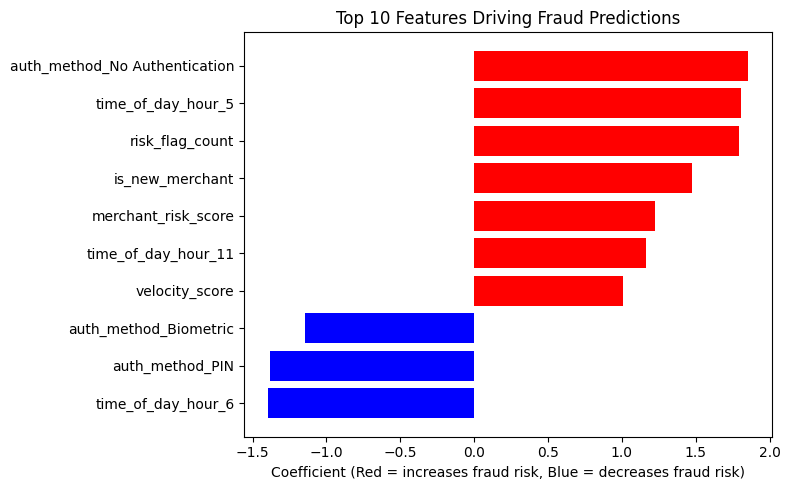

In [32]:

# Why do we look at coefficients?
# Logistic Regression makes predictions using a weighted sum of the features.
# Each coefficient tells us how much that feature "pushes" the prediction toward Fraud (positive) 
# or Not Fraud (negative).

# Get the coefficients from our final trained model
coefficients = best_log_reg.coef_[0]
feature_names = X_train.columns

# Put them into a DataFrame so we can sort and read them easily
coef_df = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients
})

# Sort by absolute value, so the most influential features (positive or negative) come first
coef_df['abs_coefficient'] = coef_df['coefficient'].abs()
coef_df = coef_df.sort_values('abs_coefficient', ascending=False)

print("--- Top 10 Most Influential Features ---")
print(coef_df[['feature', 'coefficient']].head(10))

# Visualization: top 10 features by coefficient value
top10 = coef_df.head(10).sort_values('coefficient')

plt.figure(figsize=(8,5))
colors = ['red' if c > 0 else 'blue' for c in top10['coefficient']]
plt.barh(top10['feature'], top10['coefficient'], color=colors)
plt.title('Top 10 Features Driving Fraud Predictions')
plt.xlabel('Coefficient (Red = increases fraud risk, Blue = decreases fraud risk)')
plt.tight_layout()
plt.show()